In [ ]:
# Colab setup: install packages not preinstalled on Colab (safe to re-run)
!pip install -q shap

# Reproduce-then-Extend — Building Energy Efficiency (Engineering)  ·  **Day 2 tutorial**

> **Published study.** Tsanas, A. & Xifara, A. (2012). "Accurate quantitative estimation of energy performance
> of residential buildings using statistical machine learning tools." *Energy and Buildings* 49:560–567
> (UCI Machine Learning Repository). A regression of a building's **heating load** on eight design features
> (n = 768). Here we reproduce the linear model, then extend it with the Day-2 **tree-based learners — random
> forest and gradient boosting (XGBoost)** — and **interpret** them with SHAP and partial dependence.


## Background

Tsanas and Xifara study how a building's **energy performance** depends on its **design geometry**, to help architects design more efficient buildings. Using 768 simulated building shapes, they estimate the **heating (and cooling) load** from eight geometry inputs, using a **linear regression** as the interpretable baseline alongside nonlinear machine-learning tools. The **primary conclusion** is that energy load is accurately predictable from geometry -- overall height, relative compactness, and glazing are the strongest drivers -- and that flexible learners (random forests) substantially outperform the linear model, motivating their use for this strongly nonlinear relationship.

## Data and codebook

**Unit of analysis:** a simulated residential **building design** (12 shapes and variants, via Ecotect); n = 768.

| Variable | Definition |
|---|---|
| `Y1` | heating load (kWh per m^2 of floor area) **(outcome)** |
| `X1` | relative compactness (volume-to-surface ratio, normalized) |
| `X2` | surface area (m^2) |
| `X3` | wall area (m^2) |
| `X4` | roof area (m^2) |
| `X5` | overall height (m) |
| `X6` | orientation (2/3/4/5 = N/E/S/W) |
| `X7` | glazing area (fraction of floor area) |
| `X8` | glazing-area distribution (0-5 scheme) |

## Descriptive results

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb                             # gradient boosting
import shap                                       # exact TreeSHAP explanations

In [2]:
url = 'https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/ENB2012_data.xlsx'
d = pd.read_excel(url).dropna(axis=1, how='all').dropna()
d = d.rename(columns={c: c for c in d.columns})[['Y1'] + [f'X{i}' for i in range(1, 9)]]
preds = [c for c in d.columns if c != 'Y1']
d.describe().T[['mean','std','min','max']].round(3)

,mean,std,min,max
Y1,22.307,10.090,6.01,43.10
X1,0.764,0.106,0.62,0.98
X2,671.708,88.086,514.50,808.50
X3,318.500,43.626,245.00,416.50
X4,176.604,45.166,110.25,220.50
X5,5.250,1.751,3.50,7.00
X6,3.500,1.119,2.00,5.00
X7,0.234,0.133,0.00,0.40
X8,2.812,1.551,0.00,5.00


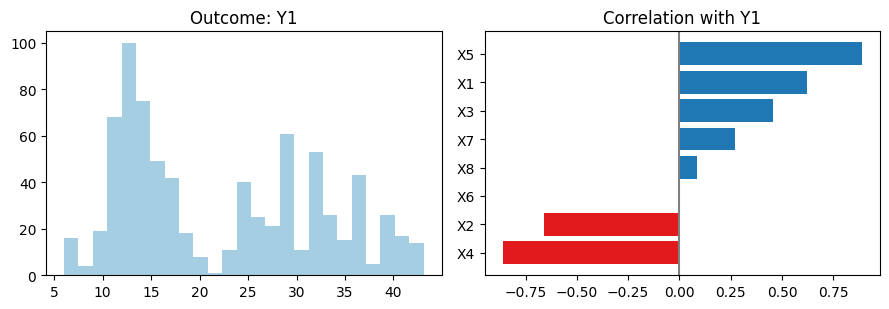

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(d['Y1'], bins=25, color='#a6cee3'); ax[0].set_title('Outcome: Y1')
cors = d[preds].corrwith(d['Y1']).sort_values()
ax[1].barh(cors.index, cors.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in cors])
ax[1].set_title('Correlation with Y1'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

In [4]:
lin = sm.OLS(d['Y1'], sm.add_constant(d[preds])).fit()
print(lin.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y1   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1187.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:35:02   Log-Likelihood:                -1912.5
No. Observations:                 768   AIC:                             3841.
Df Residuals:                     760   BIC:                             3878.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         84.0134     19.034      4.414      0.0

**Confirmation against the published study.** The linear model attains in-sample $R^2$ =
0.916, matching the ~0.92 reported by Tsanas & Xifara for their linear baseline.
Overall height (`X5`) and relative compactness (`X1`) dominate — but the fit leaves clear structure, which is
the motivation for going beyond a straight line.

## Tree-based learners: random forest & gradient boosting

The linear model already fits heating load well, but the engineering relationships are not straight lines:
compactness, glazing, and overall height act with **diminishing returns and interactions** (a large glazing
area matters more in a tall, exposed building). **Random forests** and **gradient boosting (XGBoost)** capture
that structure automatically.

We evaluate honestly: hold out a 30% test set, **tune each learner only on the training set** (the forest's
`max_features` by out-of-bag \(R^2\); XGBoost's depth × learning-rate by `xgb.cv` RMSE with early stopping),
and score once on the untouched test set — reporting held-out \(R^2\) and RMSE against the OLS baseline.

In [ ]:
X, y = d[preds].values, d['Y1'].values
tr, te = train_test_split(np.arange(len(y)), test_size=0.30, random_state=2026)
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
test_r2, test_rmse = {}, {}
rmse = lambda a, b: mean_squared_error(a, b) ** 0.5

# 1. OLS -- the published linear model
ols = sm.OLS(ytr, sm.add_constant(Xtr)).fit()
p = ols.predict(sm.add_constant(Xte, has_constant='add'))
test_r2['OLS'], test_rmse['OLS'] = r2_score(yte, p), rmse(yte, p)

# 2. random forest -- max_features tuned on the TRAINING set by out-of-bag R^2
best_rf = None
for mf in [0.33, 0.5, 1.0]:
    rf = RandomForestRegressor(n_estimators=600, max_features=mf, oob_score=True,
                               random_state=0, n_jobs=-1).fit(Xtr, ytr)
    if best_rf is None or rf.oob_score_ > best_rf[0]: best_rf = (rf.oob_score_, mf)
rf = RandomForestRegressor(n_estimators=600, max_features=best_rf[1], random_state=0, n_jobs=-1).fit(Xtr, ytr)
p = rf.predict(Xte); test_r2['RandomForest'], test_rmse['RandomForest'] = r2_score(yte, p), rmse(yte, p)

# 3. XGBoost -- depth x eta tuned by xgb.cv on the TRAINING set; nrounds via early stopping
dtr = xgb.DMatrix(Xtr, label=ytr); best = None
for depth in [2, 3, 4]:
    for eta in [0.05, 0.1]:
        r = xgb.cv({'objective': 'reg:squarederror', 'max_depth': depth, 'eta': eta,
                    'subsample': 0.9, 'colsample_bytree': 0.9, 'eval_metric': 'rmse'},
                   dtr, num_boost_round=800, nfold=5, early_stopping_rounds=25, seed=0)
        s = r['test-rmse-mean'].min()
        if best is None or s < best[0]: best = (s, depth, eta, len(r))
bst = xgb.train({'objective': 'reg:squarederror', 'max_depth': best[1], 'eta': best[2],
                 'subsample': 0.9, 'colsample_bytree': 0.9}, dtr, num_boost_round=best[3])
p = bst.predict(xgb.DMatrix(Xte)); test_r2['XGBoost'], test_rmse['XGBoost'] = r2_score(yte, p), rmse(yte, p)

print({m: round(test_r2[m], 3) for m in test_r2}, '<- held-out R^2')
print({m: round(test_rmse[m], 3) for m in test_rmse}, '<- held-out RMSE')
best_ml = 'RandomForest' if test_rmse['RandomForest'] <= test_rmse['XGBoost'] else 'XGBoost'
print(f"Best learner: {best_ml}. RMSE {test_rmse[best_ml]:.3f} vs OLS {test_rmse['OLS']:.3f} "
      f"({100*(test_rmse['OLS']-test_rmse[best_ml])/test_rmse['OLS']:.0f}% lower).")

In [ ]:
order = ['OLS', 'RandomForest', 'XGBoost']
cols = ['0.7', '#a6cee3', '#a6cee3']; cols[order.index(best_ml)] = '#1f78b4'
plt.figure(figsize=(6, 3)); bars = plt.bar(order, [test_rmse[m] for m in order], color=cols)
plt.ylabel('held-out RMSE'); plt.title('Held-out test RMSE by model (lower is better)')
for b, m in zip(bars, order): plt.text(b.get_x() + b.get_width()/2, test_rmse[m] + .05, f'{test_rmse[m]:.2f}', ha='center')
plt.tight_layout(); plt.show()

The tree ensembles cut held-out error well below OLS: heating load really does respond nonlinearly to the
building-design features, and boosting/forests capture those curves and interactions that a linear model
must approximate with a straight line.

## Interpreting the model: importance, SHAP, and partial dependence

A random forest or XGBoost has no coefficient table, so we interpret it with **impurity importance**, **SHAP
values** (each feature's signed, additive contribution to each building's predicted heating load, kWh/m² —
exact for trees via TreeSHAP), and **partial dependence** (how predicted load moves as one feature varies).

In [ ]:
rf_full = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1).fit(X, y)
bst = xgb.train({'objective': 'reg:squarederror', 'max_depth': 3, 'eta': 0.05,
                 'subsample': 0.9, 'colsample_bytree': 0.9}, xgb.DMatrix(X, label=y), num_boost_round=400)
shap_values = shap.TreeExplainer(bst).shap_values(X)     # signed contributions to predicted heating load

In [ ]:
labels = {'X1':'compactness','X2':'surface area','X3':'wall area','X4':'roof area',
          'X5':'height','X6':'orientation','X7':'glazing area','X8':'glazing distn'}
names = [labels[c] for c in preds]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
imp_rf = pd.Series(rf_full.feature_importances_, index=names).sort_values()[-8:]
ax[0].barh(imp_rf.index, imp_rf.values, color='#33a02c'); ax[0].set_title('RF importance')
imp_sh = pd.Series(np.abs(shap_values).mean(0), index=names).sort_values()[-8:]
ax[1].barh(imp_sh.index, imp_sh.values, color='#6a3d9a'); ax[1].set_title('SHAP importance'); ax[1].set_xlabel('mean(|SHAP|)')
plt.tight_layout(); plt.show()

In [ ]:
# SHAP summary (beeswarm): each point a building, coloured by the feature's value
shap.summary_plot(shap_values, pd.DataFrame(X, columns=names), feature_names=names, show=False, max_display=8)
plt.tight_layout(); plt.show()

In [ ]:
top1 = int(np.abs(shap_values).mean(0).argmax())
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
grid = np.linspace(np.quantile(X[:, top1], .02), np.quantile(X[:, top1], .98), 50)
base = np.tile(np.median(X, 0), (50, 1)); base[:, top1] = grid
ax[0].plot(grid, rf_full.predict(base), color='#1f78b4', lw=2.5)
ax[0].set_xlabel(names[top1]); ax[0].set_ylabel('predicted heating load'); ax[0].set_title('Partial dependence')
ax[1].scatter(X[:, top1], shap_values[:, top1], s=10, alpha=.3, color='#6a3d9a')
ax[1].axhline(0, ls='--', color='0.6'); ax[1].set_xlabel(names[top1]); ax[1].set_ylabel('SHAP value'); ax[1].set_title('SHAP dependence')
plt.tight_layout(); plt.show()

**Interpreting the relationships.** The dominant driver is the building's **overall compactness / surface
structure**: SHAP shows heating load rising sharply as the shape becomes less compact, then bending — a
diminishing-returns curve the OLS slope averages into a single number. Glazing area and height add smaller,
interacting contributions. The tree ensembles both **predict better** and **reveal the shape** of the
engineering relationships.

## Takeaway

This example gives Day 2 its **regression** learner tutorial: the same reproduce-then-extend workflow, but the
extension is **random forest and gradient boosting** rather than a linear or polynomial fit, evaluated on a
held-out test set and **interpreted with SHAP and partial dependence**. On a genuinely nonlinear engineering
outcome the ensembles cut held-out error well below OLS *and* expose the curves that drive heating load.

## Recommended exercises

1. Repeat the whole analysis for the **cooling load** (`Y2`) and compare which features SHAP ranks highest.
2. Add a monotonic constraint in XGBoost for compactness and see whether it helps or hurts held-out RMSE.
3. Compare the tree ensembles here against the Day-1 polynomial fit of the same data — accuracy vs interpretability.
4. Plot a SHAP dependence plot coloured by a second feature to reveal an interaction (e.g. glazing × height).